# Task 1: Preattentive attributes and visual search

**CLO1:** how the brain processes visual information.

The idea I'm testing: one feature (a different colour, or a different shape) gets found in about the same time no matter how many distractors there are. Two features at once (red *and* a circle) doesn't, and the time should climb with every extra item.

**How this notebook works.** Everything that only needs the CSV runs straight away. The experiment (step 2) needs a real person, so it lives in a function I run by hand. The analysis cells read `search_results.csv`, which that function writes. No file, no numbers.

In [1]:
import os, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output

stim = pd.read_csv("stimuli_search.csv")
COLOURS = {"red": "#ee6677", "blue": "#4477aa"}
MARKERS = {"circle": "o", "square": "s"}
print(stim.shape, "rows,", stim.trial.nunique(), "trials")

(2430, 10) rows, 90 trials


## Step 1: render one trial
One function, one `ax`. No axes, ticks or title inside it. I made the squares a bit smaller (`s=210` vs `260`) because a square at the same `s` looks heavier than a circle, and I didn't want size to leak in as a second cue.

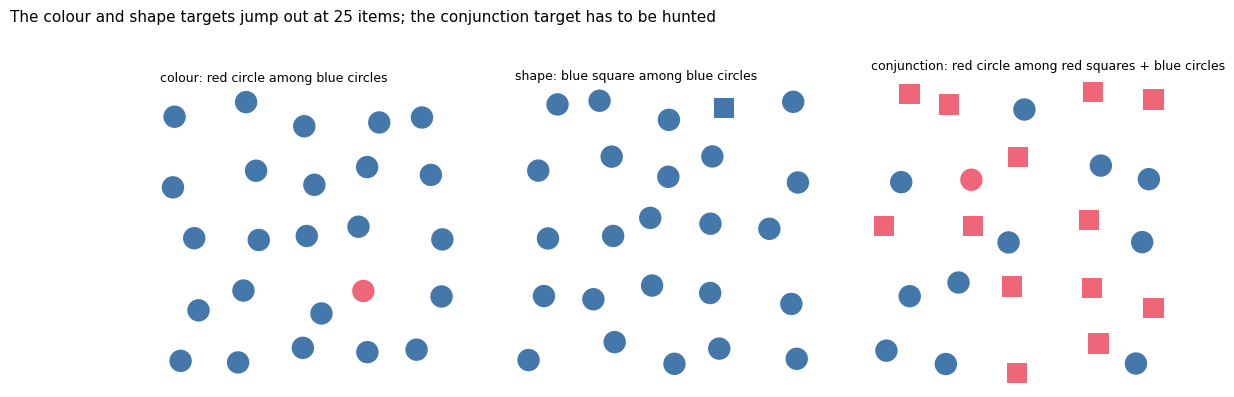

In [2]:
def draw_trial(ax, trial):
    d = stim[stim.trial == trial]
    for (colour, shape), g in d.groupby(["colour", "shape"]):
        ax.scatter(g.x, g.y, s=260 if shape == "circle" else 210,
                   color=COLOURS[colour], marker=MARKERS[shape], edgecolor="none")
    ax.set_aspect("equal")
    ax.axis("off")

# one target-present trial per condition at set_size 25
check = [stim[(stim.condition == c) & (stim.set_size == 25) & (stim.target_present == "yes")].trial.iloc[0]
         for c in ["colour", "shape", "conjunction"]]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, tr, name in zip(axes, check, ["colour: red circle among blue circles",
                                      "shape: blue square among blue circles",
                                      "conjunction: red circle among red squares + blue circles"]):
    draw_trial(ax, tr)
    ax.set_title(name, fontsize=9, loc="left")
fig.suptitle("The colour and shape targets jump out at 25 items; the conjunction target has to be hunted",
             x=0.01, ha="left", fontsize=11)
fig.savefig("t1_check_stimuli.png", dpi=300, bbox_inches="tight")
plt.show()

**What the eye does here.** In the first panel the red circle is the only red thing on the page, so hue alone separates it and I see it without looking for it. The same goes for the lone square in the middle panel: shape is the one thing that differs. In the third panel the target shares its colour with every red square and its shape with every blue circle. There is no single feature that belongs only to the target, so the eye has to check items one by one. (There's one pop-out per panel at most, and in the third there isn't any. That's the point.)

## Step 2: run the experiment on a real person

**Design.** 3 conditions x 3 set sizes (9, 25, 49) x target present/absent = **18 trials**. That is the "two per cell" from the brief once you use three set sizes (the brief says 18 trials, and 15 cells x 2 would be 30, so I went with the three sizes that give exactly 18). I picked the small, middle and large sizes so the slope has the widest spread to work with.

Trials are chosen at random from the CSV (my own seed, not the data seed). The reader gets told the target at the start of each block. Time is `time.perf_counter()` from the moment the picture is shown to the moment they hit Enter after typing `y` or `n`. That includes typing time, which is the same in every trial, so it adds a constant and doesn't change the slope.

To run it: set `RUN_EXPERIMENT = True`, type the person's first name, hand them the keyboard.

In [3]:
RUN_EXPERIMENT = False   # flip to True when a person is sitting next to you
READER = "a classmate"   # first name is fine
SIZES = [9, 25, 49]
TARGET_TEXT = {"colour": "the RED CIRCLE (everything else is blue circles)",
               "shape": "the BLUE SQUARE (everything else is blue circles)",
               "conjunction": "the RED CIRCLE (others are red squares and blue circles)"}

def run_search_experiment(reader):
    rnd = random.Random(2026)
    conditions = ["colour", "shape", "conjunction"]
    rnd.shuffle(conditions)
    rows = []
    for cond in conditions:
        block = []
        for n in SIZES:
            for present in ["yes", "no"]:
                pool = stim[(stim.condition == cond) & (stim.set_size == n) &
                            (stim.target_present == present)].trial.unique()
                block.append((cond, n, present, int(rnd.choice(list(pool)))))
        rnd.shuffle(block)
        input(f"BLOCK: {cond}. Target = {TARGET_TEXT[cond]}.  Press Enter when ready.")
        for cond_, n, present, tr in block:
            clear_output(wait=True)
            time.sleep(1.0)
            fig, ax = plt.subplots(figsize=(5, 5))
            draw_trial(ax, tr)
            plt.show()
            t0 = time.perf_counter()
            ans = ""
            while ans not in ("y", "n"):
                ans = input("Is the target there? y / n: ").strip().lower()
            rt = (time.perf_counter() - t0) * 1000
            correct = (ans == "y") == (present == "yes")
            rows.append(dict(reader=reader, trial=tr, condition=cond_, set_size=n,
                             target_present=present, response=ans,
                             correct=correct, rt_ms=round(rt, 1)))
    clear_output()
    out = pd.DataFrame(rows)
    out.to_csv("search_results.csv", index=False)
    print("saved search_results.csv,", len(out), "trials")
    return out

if RUN_EXPERIMENT:
    run_search_experiment(READER)

**Who was my reader:** _(fill in: first name, how old-ish, any glasses/colour-blindness they mentioned, how long the 18 trials took)_

**What I asked:** "Is the target there, yes or no?", told the target before each block, answered on the keyboard.

## Step 3: response time against set size (target-present only)
Colour is the pop-out here, so it gets the one strong colour. The conjunction line is what the whole task is about, so that one is red and the other two are grey. Each line is labelled at its right end, so nothing depends on colour alone. Absent trials are kept out of the plot on purpose.

In [4]:
have_data = os.path.exists("search_results.csv")
if have_data:
    res = pd.read_csv("search_results.csv")
    print("trials:", len(res), "| wrong answers:", int((~res.correct).sum()))
    print(res.groupby(["condition", "target_present"]).rt_ms.mean().round(0).unstack())
else:
    print("search_results.csv doesn't exist yet. Run the experiment (RUN_EXPERIMENT = True) and re-run this notebook.")

search_results.csv doesn't exist yet. Run the experiment (RUN_EXPERIMENT = True) and re-run this notebook.


In [5]:
if have_data:
    present = res[(res.target_present == "yes") & (res.correct)]
    mean_rt = present.groupby(["condition", "set_size"]).rt_ms.mean().reset_index()
    slopes = {}
    fig, ax = plt.subplots(figsize=(8, 5))
    for cond in ["colour", "shape", "conjunction"]:
        d = mean_rt[mean_rt.condition == cond].sort_values("set_size")
        slope, intercept = np.polyfit(d.set_size, d.rt_ms, 1)
        slopes[cond] = slope
        strong = cond == "conjunction"
        ax.plot(d.set_size, d.rt_ms, marker="o", lw=2.5 if strong else 1.6,
                color="#ee6677" if strong else "#aaaaaa")
        ax.annotate(cond, (d.set_size.iloc[-1], d.rt_ms.iloc[-1]), xytext=(6, 0),
                    textcoords="offset points", va="center",
                    color="#cc3355" if strong else "#777777")
    ax.set_xticks(SIZES)
    ax.set_ylim(0, None)
    ax.set_title(f"One reader: conjunction search slows by {slopes['conjunction']:.0f} ms per item; "
                 f"colour {slopes['colour']:.0f}, shape {slopes['shape']:.0f}", loc="left", fontsize=11)
    ax.set_xlabel("Items on screen (set size)")
    ax.set_ylabel("Response time, target present (ms)")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.text(0, -0.2, f"n = {len(present)} correct target-present trials from 1 reader "
                     f"({READER}); each point is one trial. Target-absent trials excluded.",
            transform=ax.transAxes, fontsize=8, color="#666666")
    fig.savefig("t1_rt_vs_setsize.png", dpi=300, bbox_inches="tight")
    plt.show()

## Step 4: the slopes
`numpy.polyfit`, degree 1, set size on x, response time on y. The slope is milliseconds per extra item.

In [6]:
if have_data:
    table = pd.DataFrame({"slope_ms_per_item": pd.Series(slopes).round(1)})
    table["reading"] = ["flat (parallel)" if abs(s) < 5 else "rising (serial)" for s in table.slope_ms_per_item]
    print(table)
    print("\nTarget-absent means (kept separate):")
    print(res[res.target_present == "no"].groupby(["condition", "set_size"]).rt_ms.mean().round(0).unstack())

**My reading (write this after you see your numbers).** Which slopes are near zero, which one rises, and by how much? If a slope came out the wrong way round, say that and give the reason: only one trial per point, the reader learned where things sit, the 9-item display being too easy, and so on. With one trial behind each point, one slow answer moves a slope a lot, so I'm reporting this as one reader, not as a result about people.

_Your numbers here:_
- colour slope: ___ ms/item
- shape slope: ___ ms/item
- conjunction slope: ___ ms/item
- Did it match the theory? ___

## Step 5: why red is instant, circle is instant, red-and-circle isn't
Colour is handled by one set of detectors and shape by another, and each set works across the whole display at once. So "is there any red?" gets answered for all items together, and so does "is there any circle?". The problem with the conjunction is that the answer to "red AND circle" isn't sitting in either detector. Both detectors fire for plenty of items (every red square, every blue circle), and nothing tells you which red thing is the same item as which circle thing. To bind the two features to one object, attention has to land on an item and check both. That's one item at a time, so the time grows with the item count. Every distractor in this experiment shares exactly one feature with the target, which is why it's a nasty display.

**A chart where I did this to a reader without noticing.** A scatter plot where colour shows one category and marker shape shows another, and the reader is asked to find, say, "the red triangles". I've made that chart (the usual iris scatter with species as colour and a second variable as shape) and it works fine for 20 points and falls apart for 150. The fix is to pick one of them as the pop-out and show the other with position or small multiples. *(Swap this for the actual Week 1 chart you had in mind if it was a different one.)*